# Beslisboom maken waarbij je zelf de features kunt kiezen

In dit notebook trainen we op basis van de synthetische data van Lighthouse een eenvoudige beslisboom. Het notebook geeft suggesties voor features, maar de gebruiker kan zelf een lijstje opgeven van features die je wil opnemen. Met de hyperparameter max_depth kan je bepalen hoe groot de boom wordt.

Doel is voor: kijken wat het effect is als je bepaalde features wel of niet opneemt.

In [49]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
data_path = Path('synth_data_scored.csv')
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()  # remove accidental whitespace from column names
target_column = 'Ja'
df.drop(columns=['Nee'], inplace=True)


print('Data shape:', df.shape)
print('Target column exists:', target_column in df.columns)
print('Target summary:')
print(df[target_column].describe())
print('First rows of target:')
print(df[target_column].head())

Data shape: (12645, 316)
Target column exists: True
Target summary:
count    12645.000000
mean         0.611877
std          0.085205
min          0.270290
25%          0.560333
50%          0.622461
75%          0.673064
max          0.833048
Name: Ja, dtype: float64
First rows of target:
0    0.600234
1    0.748566
2    0.781536
3    0.613350
4    0.688989
Name: Ja, dtype: float64


## Feature impact candidates

Overzicht van de features die een sterke relatie hebben met de target - kan overgeslagen worden

In [51]:
numeric_features = df.select_dtypes(include=[np.number]).columns.drop(target_column)
correlations = df[numeric_features].corrwith(df[target_column]).abs().sort_values(ascending=False)

print('Top numeric candidate features by absolute Pearson correlation to Ja:')
impact_df = correlations.head(20).rename('abs_corr').to_frame()
display(impact_df)

print('\nA higher absolute correlation suggests a stronger linear relationship with the target.\n')

feature_counts = df[numeric_features].nunique().loc[impact_df.index]
feature_impact = impact_df.assign(unique_values=feature_counts)
print('Top candidate features with distinct value counts:')
display(feature_impact)

Top numeric candidate features by absolute Pearson correlation to Ja:


c:\Users\rik\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\rik\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,abs_corr
relatie_overig_actueel_vorm__kostendeler,0.430474
contacten_onderwerp_no_show,0.326164
relatie_overig_kostendeler,0.324221
persoon_leeftijd_bij_onderzoek,0.312851
relatie_overig_historie_vorm__kostendeler,0.302171
pla_hist_pla_categorie_doelstelling_16,0.296770
afspraak_resultaat_ingevuld_uniek,0.292307
contacten_onderwerp_overleg_met_inkomen,0.283292
pla_historie_ontwikkeling,0.275679
instrument_ladder_huidig_activering,0.259341



A higher absolute correlation suggests a stronger linear relationship with the target.

Top candidate features with distinct value counts:


,abs_corr,unique_values
relatie_overig_actueel_vorm__kostendeler,0.430474,5
contacten_onderwerp_no_show,0.326164,7
relatie_overig_kostendeler,0.324221,2
persoon_leeftijd_bij_onderzoek,0.312851,49
relatie_overig_historie_vorm__kostendeler,0.302171,7
pla_hist_pla_categorie_doelstelling_16,0.296770,4
afspraak_resultaat_ingevuld_uniek,0.292307,10
contacten_onderwerp_overleg_met_inkomen,0.283292,7
pla_historie_ontwikkeling,0.275679,2
instrument_ladder_huidig_activering,0.259341,4


## Feature selection

Bepaal zelf welke features je wil opnemen door de namen op te voeren. Als je bv een tikfout maakt krijg je een foutmelding. Je kunt zo veel of weinig features opnemen als je wil.

In [ ]:
selected_features = [
    'persoon_geslacht_vrouw',
    'relatie_kind_huidige_aantal',
   # 'relatie_partner_huidige_partner___partner__gehuwd_',
   # 'adres_aantal_brp_adres',
   # 'persoon_leeftijd_bij_onderzoek',
   # 'belemmering_hist_verslavingsproblematiek',
    'belemmering_financiele_problemen',
    'persoonlijke_eigenschappen_spreektaal_anders'
]

missing = [c for c in selected_features if c not in df.columns]
if missing:
    raise ValueError(f'Missing selected features in the dataset: {missing}')

X = df[selected_features].copy()
y = df[target_column].copy()

print('Using', len(selected_features), 'features:')
for feature in selected_features:
    print('-', feature)

Using 4 features:
- persoon_geslacht_vrouw
- relatie_kind_huidige_aantal
- belemmering_financiele_problemen
- persoonlijke_eigenschappen_spreektaal_anders


## Train / test split, scaling and model training

Het daadwerkelijk trainen van het model inclusief de voorbereiding van de dataset bestaande uit de gekozen features

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

max_depth = 3  # set tree depth here before training
model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
model.fit(X_train_scaled, y_train)

print(f'Model trained successfully with max_depth={max_depth}')
print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Model trained successfully with max_depth=3
Training set size: 9483
Test set size: 3162


Inferentie - testen hoe goed het model haar werk doet - kan overgeslagen worden

In [80]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Evaluation on test set:')
print(f'  MAE : {mae:.5f}')
print(f'  RMSE: {rmse:.5f}')
print(f'  R2  : {r2:.5f}')



Evaluation on test set:
  MAE : 0.06528
  RMSE: 0.08377
  R2  : 0.02774


c:\Users\rik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


## Decision tree visualization

Laten zien hoe de beslisboom eruit ziet om te bekijken wat die doet met de features die je hebt opgegeven.

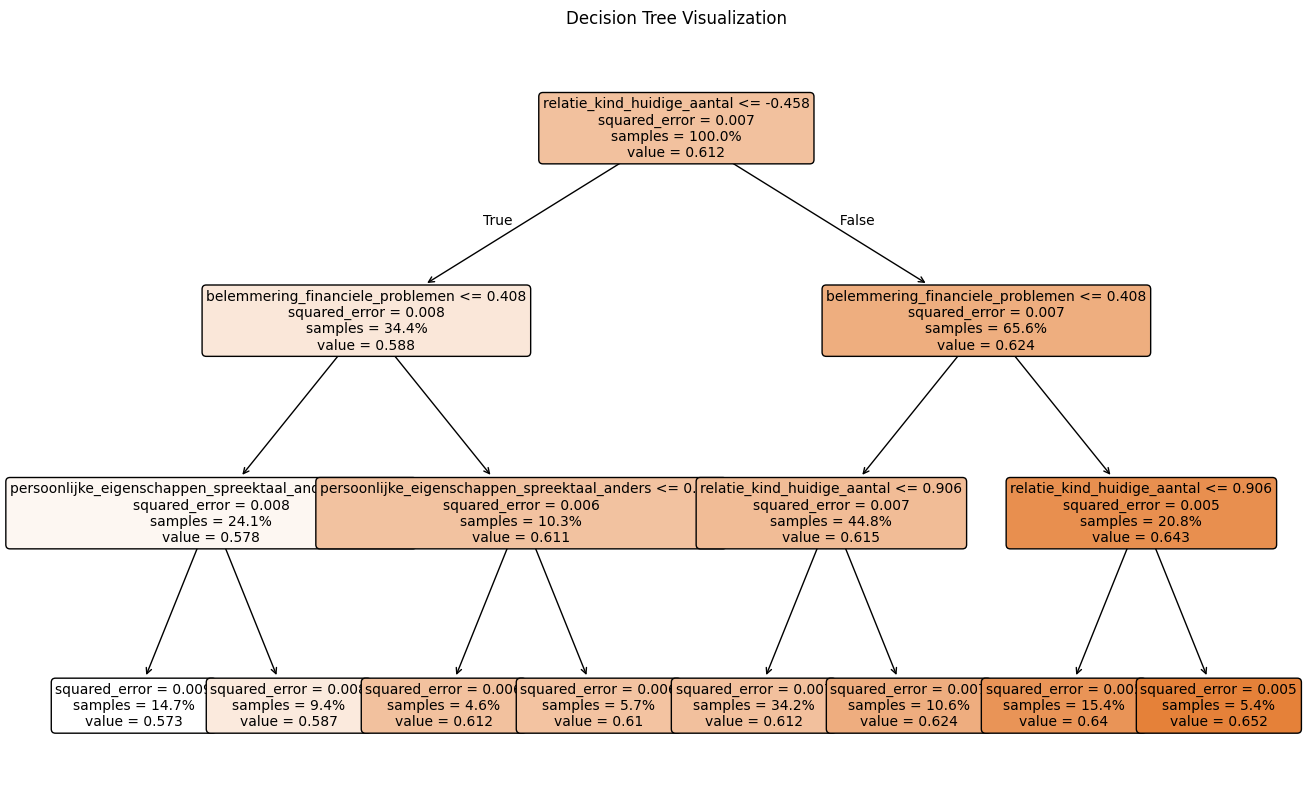

In [81]:
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    precision=3
)
plt.title('Decision Tree Visualization')
plt.show()

## Feature importances and tree structure

Analyse van de gebruikte features, alleen gebruiken als je het interessant vindt

,feature,importance
1,relatie_kind_huidige_aantal,0.450284
5,belemmering_financiele_problemen,0.272819
3,adres_aantal_brp_adres,0.194473
0,persoon_geslacht_vrouw,0.025561
4,belemmering_hist_verslavingsproblematiek,0.021570
6,persoonlijke_eigenschappen_spreektaal_anders,0.020375
2,relatie_partner_huidige_partner___partner__geh...,0.014918


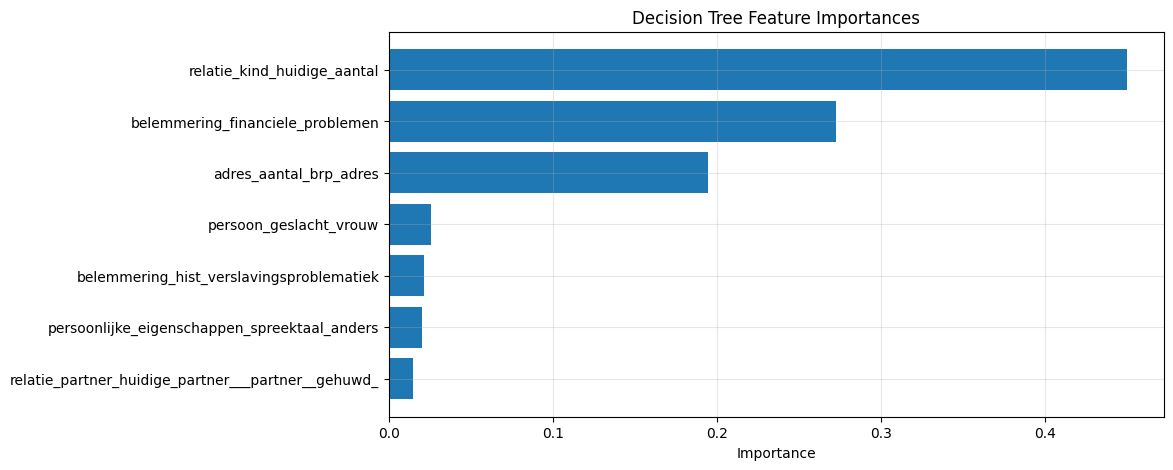

Tree structure (first levels):
|--- relatie_kind_huidige_aantal <= -0.46
|   |--- belemmering_financiele_problemen <= 0.41
|   |   |--- adres_aantal_brp_adres <= -0.94
|   |   |   |--- persoonlijke_eigenschappen_spreektaal_anders <= 0.05
|   |   |   |   |--- persoon_geslacht_vrouw <= 0.03
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- persoon_geslacht_vrouw >  0.03
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- persoonlijke_eigenschappen_spreektaal_anders >  0.05
|   |   |   |   |--- belemmering_hist_verslavingsproblematiek <= 1.88
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- belemmering_hist_verslavingsproblematiek >  1.88
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- adres_aantal_brp_adres >  -0.94
|   |   |   |--- persoon_geslacht_vrouw <= 0.03
|   |   |   |   |--- persoonlijke_eigenschappen_spreektaal_anders <= 0.05
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   

In [ ]:
import pandas as pd
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.grid(True, alpha=0.3)
plt.show()